In [8]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from dataclasses import replace

import numpy as np
import matplotlib.pyplot as plt

from kuramoto.experiments import evaluate_metric_scores
from kuramoto.analysis import order_parameter
from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
)

# -----------------------------------------------------------------------------
# Global notebook knobs
# -----------------------------------------------------------------------------

grid_shape = (12, 12)
T_END = 10.0
dt = 0.01

# Ensemble size per case
N_SEEDS = 5
BASE_SEED = 42

# Lesion study hyperparameters
n_random_repeats = 10
lesion_fracs = np.arange(0, 0.3, 0.02)
lesion_strength = 1.0

# Quick smoke mode (set True to iterate faster)
QUICK_MODE = False
if QUICK_MODE:
    N_SEEDS = 1
    lesion_fracs = np.arange(0, 0.3, 0.05)
    n_random_repeats = 3


# -----------------------------------------------------------------------------
# Case builders
# -----------------------------------------------------------------------------

def bottleneck_group_ids(grid_shape: tuple[int, int]) -> list[int]:
    n_rows, n_cols = grid_shape
    group_ids = np.zeros((n_rows, n_cols), dtype=int)
    group_ids[n_rows // 2 :, :] = 1  # bottom half
    group_ids[n_rows // 2 - 2 : n_rows // 2 + 2, n_cols // 2 - 2 : n_cols // 2 + 2] = 2  # central block
    return group_ids.ravel().tolist()


def random_group_ids(grid_shape: tuple[int, int], n_groups: int, rng: np.random.Generator) -> list[int]:
    n = int(np.prod(grid_shape))
    return rng.integers(0, n_groups, size=n, endpoint=False).astype(int).tolist()


def bottleneck_components_gaussian() -> list[KernelComponentConfig]:
    return [
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=1.0,
            kernel_params={"sigma": 1.0},
            radius=2.0,
            node_groups=[0],
            edge_mode="within",
        ),
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=1.0,
            kernel_params={"sigma": 1.0},
            radius=2.0,
            node_groups=[1],
            edge_mode="within",
        ),
        # bottleneck-like hub (group 2) coupling to/from everyone
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=0.8,
            kernel_params={"sigma": 4.0},
            radius=4.0,
            node_groups=[2],
            edge_mode="outgoing",
        ),
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=0.8,
            kernel_params={"sigma": 4.0},
            radius=4.0,
            node_groups=[2],
            edge_mode="incoming",
        ),
        # weak one-way coupling from group 1 to group 0
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=0.2,
            kernel_params={"sigma": 2.0},
            radius=2.0,
            node_groups=[1],
            edge_mode="custom",
            to_node_groups=[0],
        ),
    ]


def components_swap_kernel(
    components: list[KernelComponentConfig],
    *,
    kernel: str,
    kernel_params: dict,
) -> list[KernelComponentConfig]:
    out: list[KernelComponentConfig] = []
    for c in components:
        out.append(replace(c, kernel=kernel, kernel_params=dict(kernel_params)))
    return out


def random_group_components_gaussian(n_groups: int = 5) -> list[KernelComponentConfig]:
    comps: list[KernelComponentConfig] = []

    # Strong within-group coupling
    for g in range(n_groups):
        comps.append(
            KernelComponentConfig(
                kernel="gaussian",
                base_strength=1.0,
                kernel_params={"sigma": 1.0},
                radius=2.0,
                node_groups=[g],
                edge_mode="within",
            )
        )

    # Weak global background coupling to allow global sync when conditions permit
    comps.append(
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=0.15,
            kernel_params={"sigma": 3.0},
            radius=4.0,
            node_groups=None,
            edge_mode="within",
        )
    )

    return comps


def random_group_components_mexican_hat(n_groups: int = 5) -> list[KernelComponentConfig]:
    mh_params = {"sigma_e": 1.0, "sigma_i": 3.0, "a_e": 1.0, "a_i": 0.8}

    comps: list[KernelComponentConfig] = []

    for g in range(n_groups):
        comps.append(
            KernelComponentConfig(
                kernel="mexican_hat",
                base_strength=1.0,
                kernel_params=mh_params,
                radius=4.0,
                node_groups=[g],
                edge_mode="within",
            )
        )

    # No global background term by default here (keeps the regime more pattern-forming / less globally sync)
    return comps


def random_group_components_mixed(n_groups: int = 5) -> list[KernelComponentConfig]:
    mh_params = {"sigma_e": 1.0, "sigma_i": 3.0, "a_e": 1.0, "a_i": 0.8}
    comps: list[KernelComponentConfig] = []

    for g in range(n_groups):
        if g < 3:
            comps.append(
                KernelComponentConfig(
                    kernel="gaussian",
                    base_strength=1.0,
                    kernel_params={"sigma": 1.0},
                    radius=2.0,
                    node_groups=[g],
                    edge_mode="within",
                )
            )
        else:
            comps.append(
                KernelComponentConfig(
                    kernel="mexican_hat",
                    base_strength=1.0,
                    kernel_params=mh_params,
                    radius=4.0,
                    node_groups=[g],
                    edge_mode="within",
                )
            )

    # weak global Gaussian background
    comps.append(
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=0.1,
            kernel_params={"sigma": 3.0},
            radius=4.0,
            node_groups=None,
            edge_mode="within",
        )
    )

    return comps


def make_case_config(case_name: str, *, seed: int) -> tuple[SimulationConfig, dict]:
    rng = np.random.default_rng(seed)

    init_theta = InitThetaConfig(mode="uniform")
    init_omega = InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3)

    n_groups = 5

    if case_name == "bottleneck_gaussian":
        group_ids = bottleneck_group_ids(grid_shape)
        components = bottleneck_components_gaussian()
        label = "Bottleneck + Gaussian"

    elif case_name == "bottleneck_mexican_hat":
        group_ids = bottleneck_group_ids(grid_shape)
        base = bottleneck_components_gaussian()
        mh_params = {"sigma_e": 1.0, "sigma_i": 3.0, "a_e": 1.0, "a_i": 0.8}
        components = components_swap_kernel(base, kernel="mexican_hat", kernel_params=mh_params)
        label = "Bottleneck + Mexican-hat"

    elif case_name == "random_groups_gaussian":
        group_ids = random_group_ids(grid_shape, n_groups=n_groups, rng=rng)
        components = random_group_components_gaussian(n_groups=n_groups)
        label = "Random-groups(5) + Gaussian"

    elif case_name == "random_groups_mixed":
        group_ids = random_group_ids(grid_shape, n_groups=n_groups, rng=rng)
        components = random_group_components_mixed(n_groups=n_groups)
        label = "Random-groups(5) + Mixed"

    elif case_name == "random_groups_mexican_hat":
        group_ids = random_group_ids(grid_shape, n_groups=n_groups, rng=rng)
        components = random_group_components_mexican_hat(n_groups=n_groups)
        label = "Random-groups(5) + Mexican-hat"

    else:
        raise ValueError(f"Unknown case_name: {case_name!r}")

    cfg = SimulationConfig(
        grid=GridConfig(shape=grid_shape, periodic=False),
        coupling=CouplingConfig(
            kernel="gaussian",
            base_strength=1.0,
            radius=4.0,
            mode="spatial",
            components=components,
            group_ids=group_ids,
        ),
        initial_theta=init_theta,
        initial_omega=init_omega,
        seed=seed,
    )

    meta = {
        "case_name": case_name,
        "case_label": label,
        "seed": seed,
        "n_groups": n_groups,
    }
    return cfg, meta


case_names = [
    "bottleneck_gaussian",
    "bottleneck_mexican_hat",
    "random_groups_gaussian",
    "random_groups_mixed",
    "random_groups_mexican_hat",
]

case_labels = {
    name: make_case_config(name, seed=BASE_SEED)[1]["case_label"] for name in case_names
}


# -----------------------------------------------------------------------------
# Ensemble runner
# -----------------------------------------------------------------------------

results: dict[str, dict[int, dict]] = {name: {} for name in case_names}
base_Rt: dict[str, dict[int, np.ndarray]] = {name: {} for name in case_names}

seeds = [BASE_SEED + i for i in range(N_SEEDS)]

for case_name in case_names:
    for seed in seeds:
        print(f"\n=== Case={case_name} seed={seed} ===")
        cfg, meta = make_case_config(case_name, seed=seed)

        sim = build_simulation(config=cfg, rng=np.random.default_rng(seed))

        # base behavior sanity trace
        res_base = sim.run((0, T_END), dt, rng=np.random.default_rng(seed))
        Rt, _ = order_parameter(res_base["theta"])
        base_Rt[case_name][seed] = np.asarray(Rt)

        # metric evaluation (this re-runs base sim internally; kept for now)
        metric_scores = evaluate_metric_scores(
            sim,
            T_END,
            dt,
            np.random.default_rng(seed),
            n_random_repeats=n_random_repeats,
            lesion_fracs=lesion_fracs,
            lesion_strength=lesion_strength,
            verbose=False,
        )

        results[case_name][seed] = metric_scores


# -----------------------------------------------------------------------------
# Aggregation utilities
# -----------------------------------------------------------------------------

def list_metrics(results_for_case: dict[int, dict]) -> list[str]:
    any_seed = next(iter(results_for_case.keys()))
    return sorted(results_for_case[any_seed].keys())


def aggregate_scores(results: dict[str, dict[int, dict]]) -> dict:
    out = {}
    for case_name, by_seed in results.items():
        metrics = list_metrics(by_seed)

        out[case_name] = {
            "metrics": metrics,
            "ABC_mean": {},
            "ABC_std": {},
            "AUC_ranked_mean": {},
            "AUC_ranked_std": {},
            "AUC_random_mean": {},
            "AUC_random_std": {},
            "R_avg_ranked_mean": {},
            "R_avg_ranked_std": {},
            "R_avg_random_mean": {},
            "R_avg_random_std": {},
        }

        for m in metrics:
            ABC = np.array([by_seed[s][m]["ABC"] for s in by_seed])
            AUC_r = np.array([by_seed[s][m]["AUC_ranked"] for s in by_seed])
            AUC_rand = np.array([by_seed[s][m]["AUC_random"] for s in by_seed])

            R_ranked = np.array([by_seed[s][m]["R_avg_ranked"] for s in by_seed], dtype=float)
            R_random = np.array([by_seed[s][m]["R_avg_random"] for s in by_seed], dtype=float)

            out[case_name]["ABC_mean"][m] = float(np.mean(ABC))
            out[case_name]["ABC_std"][m] = float(np.std(ABC))

            out[case_name]["AUC_ranked_mean"][m] = float(np.mean(AUC_r))
            out[case_name]["AUC_ranked_std"][m] = float(np.std(AUC_r))

            out[case_name]["AUC_random_mean"][m] = float(np.mean(AUC_rand))
            out[case_name]["AUC_random_std"][m] = float(np.std(AUC_rand))

            out[case_name]["R_avg_ranked_mean"][m] = np.mean(R_ranked, axis=0)
            out[case_name]["R_avg_ranked_std"][m] = np.std(R_ranked, axis=0)

            out[case_name]["R_avg_random_mean"][m] = np.mean(R_random, axis=0)
            out[case_name]["R_avg_random_std"][m] = np.std(R_random, axis=0)

    return out


agg = aggregate_scores(results)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

=== Case=bottleneck_gaussian seed=42 ===
Evaluating deg_base...
Evaluating deg_eff...
Evaluating deg_C_avg...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating closeness_C_avg...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating betweenness_C_avg...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvector_C_avg...
Evaluating I_final_base...
Evaluating I_final_eff...
Evaluating I_mean_base...
Evaluating I_mean_eff...
Evaluating dRf_dalpha...
Evaluating dRm_dalpha...

=== Case=bottleneck_gaussian seed=43 ===
Evaluating deg_base...
Evaluating deg_eff...
Evaluating deg_C_avg...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating closeness_C_avg...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating betweenness_C_avg...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvector

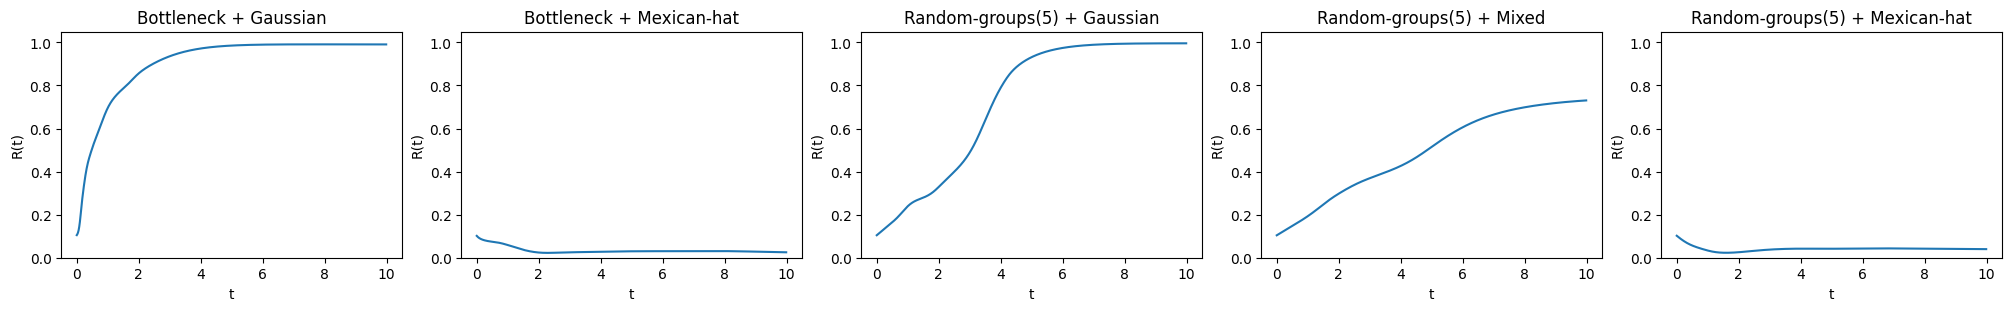

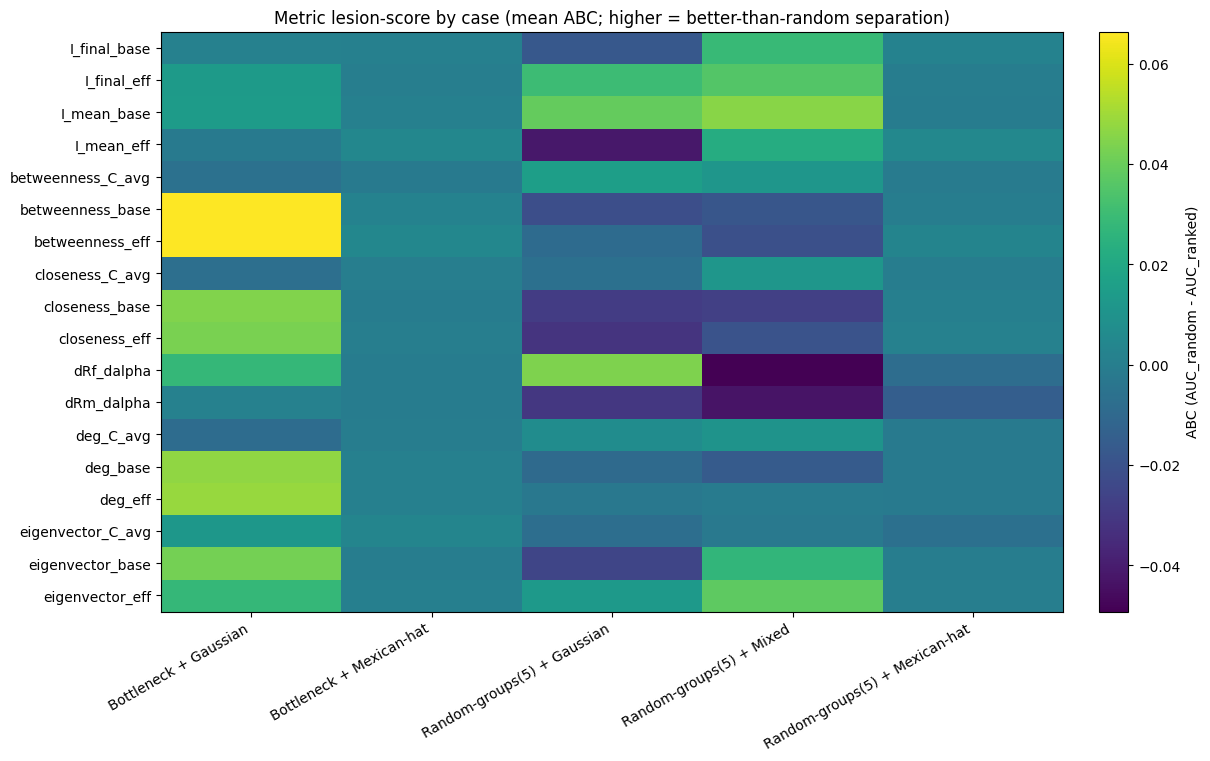

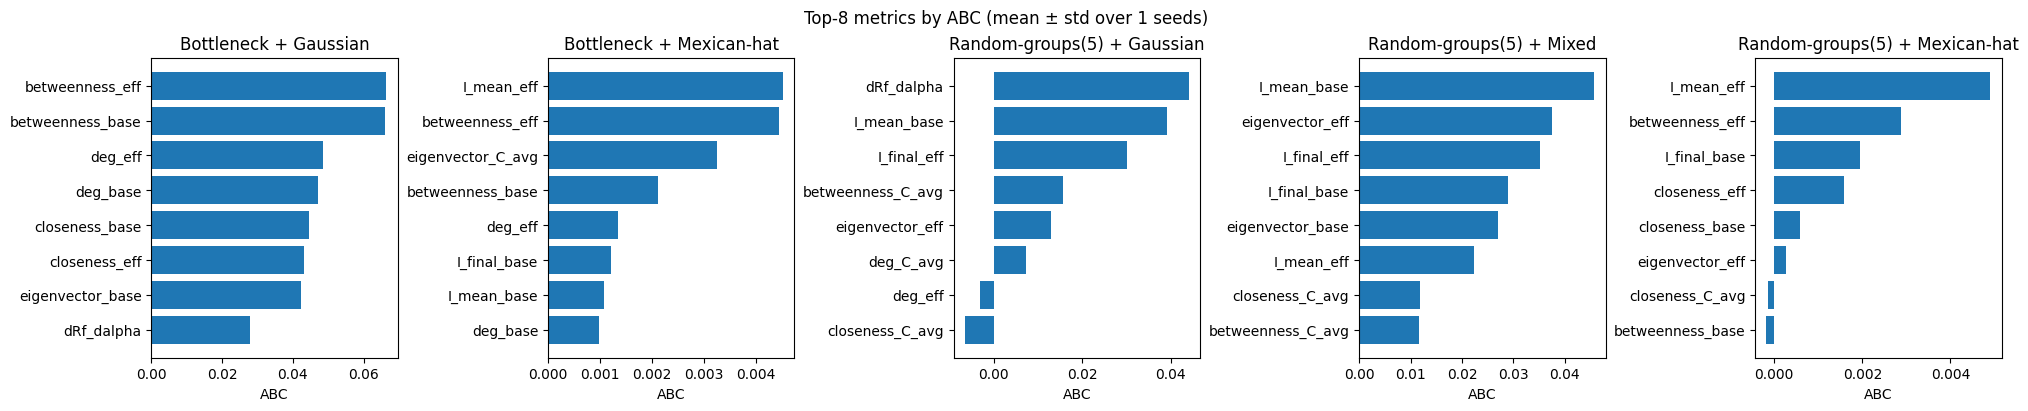

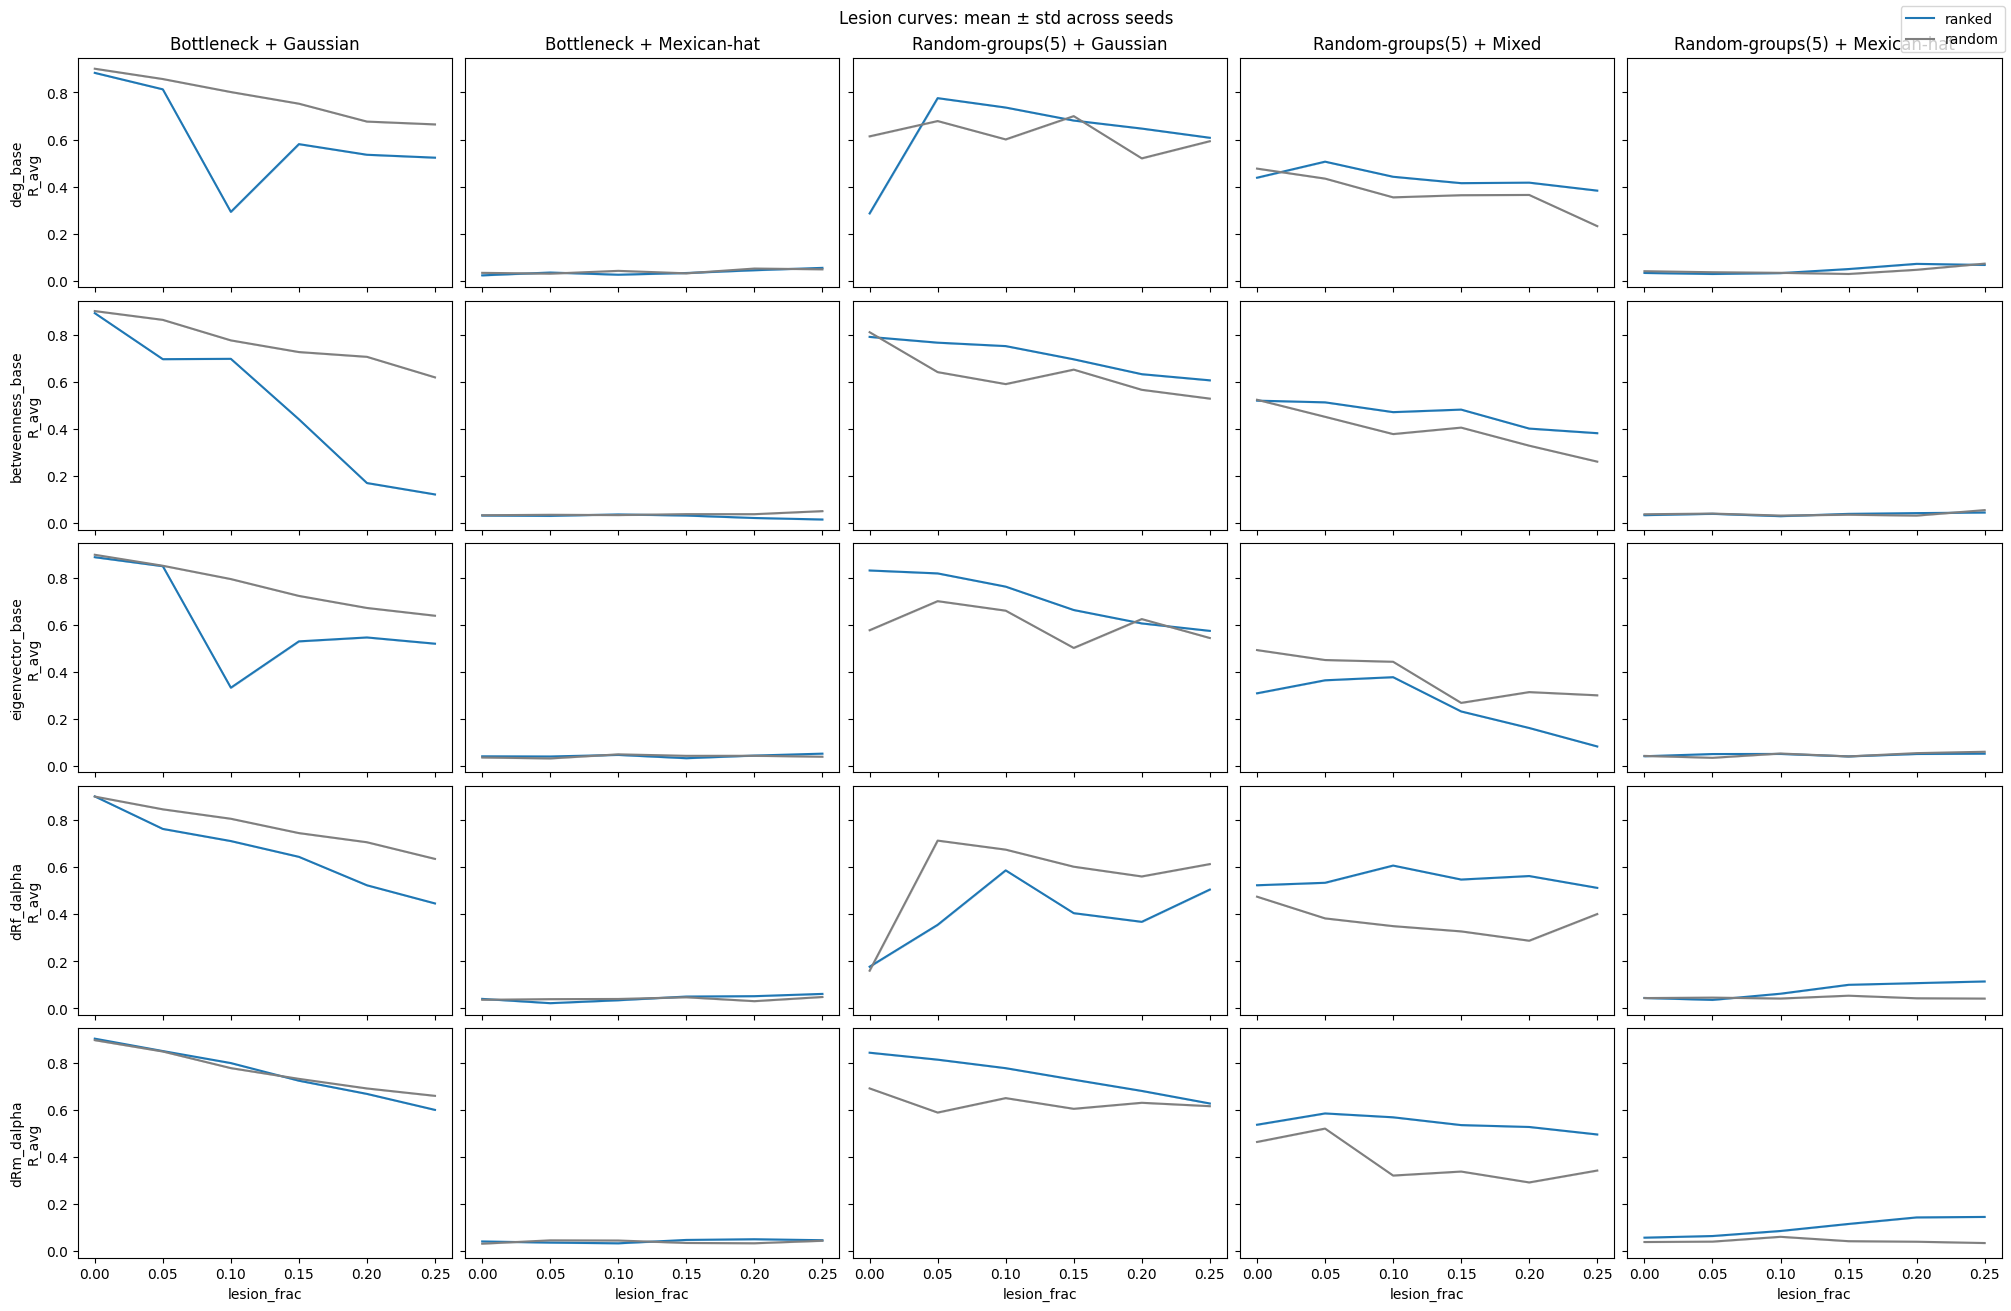

In [7]:
# -----------------------------------------------------------------------------
# Plots
# -----------------------------------------------------------------------------

# 1) R(t) sanity checks (one representative seed per case)
fig, axs = plt.subplots(1, len(case_names), figsize=(4 * len(case_names), 3), constrained_layout=True)
for ax, case_name in zip(axs, case_names):
    seed0 = seeds[0]
    Rt = base_Rt[case_name][seed0]
    ax.plot(np.arange(Rt.shape[0]) * dt, Rt)
    ax.set_title(case_labels[case_name])
    ax.set_xlabel("t")
    ax.set_ylabel("R(t)")
    ax.set_ylim(0, 1.05)
plt.show()


# 2) ABC heatmap: metrics x cases
metrics = agg[case_names[0]]["metrics"]
heat = np.array([[agg[c]["ABC_mean"][m] for c in case_names] for m in metrics], dtype=float)

fig, ax = plt.subplots(figsize=(1.2 * len(case_names) + 6, 0.25 * len(metrics) + 3), constrained_layout=True)
im = ax.imshow(heat, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(case_names)))
ax.set_xticklabels([case_labels[c] for c in case_names], rotation=30, ha="right")
ax.set_yticks(np.arange(len(metrics)))
ax.set_yticklabels(metrics)
ax.set_title("Metric lesion-score by case (mean ABC; higher = better-than-random separation)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ABC (AUC_random - AUC_ranked)")
plt.show()


# 3) Top-k metrics per case (by mean ABC)
TOP_K = 8
fig, axs = plt.subplots(1, len(case_names), figsize=(4 * len(case_names), 4), constrained_layout=True, sharex=False)
for ax, case_name in zip(axs, case_names):
    items = [(m, agg[case_name]["ABC_mean"][m], agg[case_name]["ABC_std"][m]) for m in metrics]
    items.sort(key=lambda x: x[1], reverse=True)
    items = items[:TOP_K]

    names = [x[0] for x in items][::-1]
    means = [x[1] for x in items][::-1]
    stds = [x[2] for x in items][::-1]

    ax.barh(names, means, xerr=stds)
    ax.set_title(case_labels[case_name])
    ax.set_xlabel("ABC")

plt.suptitle(f"Top-{TOP_K} metrics by ABC (mean ± std over {N_SEEDS} seeds)")
plt.show()


# 4) Lesion curves (small multiples) for a shortlist of metrics
plot_metrics = [
    "deg_base",
    "betweenness_base",
    "eigenvector_base",
    "dRf_dalpha",
    "dRm_dalpha",
]
plot_metrics = [m for m in plot_metrics if m in metrics]

nrows = len(plot_metrics)
fig, axs = plt.subplots(nrows, len(case_names), figsize=(4 * len(case_names), 2.6 * nrows), constrained_layout=True, sharex=True, sharey=True)
if nrows == 1:
    axs = np.expand_dims(axs, axis=0)

for r, metric in enumerate(plot_metrics):
    for c, case_name in enumerate(case_names):
        ax = axs[r, c]
        x = lesion_fracs

        y = agg[case_name]["R_avg_ranked_mean"][metric]
        yerr = agg[case_name]["R_avg_ranked_std"][metric]
        ax.plot(x, y, label="ranked", color="tab:blue")
        ax.fill_between(x, y - yerr, y + yerr, color="tab:blue", alpha=0.2)

        y0 = agg[case_name]["R_avg_random_mean"][metric]
        y0err = agg[case_name]["R_avg_random_std"][metric]
        ax.plot(x, y0, label="random", color="tab:gray")
        ax.fill_between(x, y0 - y0err, y0 + y0err, color="tab:gray", alpha=0.2)

        if r == 0:
            ax.set_title(case_labels[case_name])
        if c == 0:
            ax.set_ylabel(f"{metric}\nR_avg")
        if r == nrows - 1:
            ax.set_xlabel("lesion_frac")

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.suptitle("Lesion curves: mean ± std across seeds")
plt.show()